<a href="https://colab.research.google.com/github/ishuu9837/temp/blob/main/Abnormal_Learning_Behaviour_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [101]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/features_df.csv')
print(df.shape)
print(df.columns.tolist())
df.head(3)

(993, 13)
['roll_no', 'name', 'pseudocode_attendance_rate', 'pseudocode_avg_score', 'coding_practice_solved_pct', 'coding_test_overall_score', 'coding_test_attendance', 'weekly_score_consistency', 'practice_problems_solved', 'weeks_zero_activity', 'anomaly_score', 'is_anomaly', 'severity']


,roll_no,name,pseudocode_attendance_rate,pseudocode_avg_score,coding_practice_solved_pct,coding_test_overall_score,coding_test_attendance,weekly_score_consistency,practice_problems_solved,weeks_zero_activity,anomaly_score,is_anomaly,severity
0,2023001753,Padamati Navdeep Goud,43.33,80.00,0.0,86.67,2.0,65.6,12.9,0,0.068583,False,LOW
1,2023001493,B Vishwajanani,43.33,46.67,45.0,46.67,2.4,53.8,15.4,0,0.021085,False,LOW
2,2023001843,Aasmitha Malavika Joshi,53.33,86.67,0.0,53.33,2.4,40.8,15.4,0,0.050939,False,LOW


In [102]:
np.random.seed(42)

FEATURE_NAMES = [
    'pseudocode_attendance_rate',
    'pseudocode_avg_score',
    'coding_practice_solved_pct',
    'coding_test_overall_score',
    'coding_test_attendance',
    'weekly_score_consistency',
    'practice_problems_solved',
    'weeks_zero_activity',
]

print(f' Dataset loaded: {df.shape}')
print(f'   Normal    : {(~df.is_anomaly).sum()}')
print(f'   Anomalous : {(df.is_anomaly).sum()}')

 Dataset loaded: (993, 13)
   Normal    : 943
   Anomalous : 50


In [103]:
class DeepAutoencoder:
    def __init__(self):
        self.input_dim  = 8
        self.latent_dim = 4
        self.scaler     = MinMaxScaler()
        self.threshold  = None
        np.random.seed(42)
        self.W_enc = np.random.randn(self.input_dim, self.latent_dim) * 0.3
        self.b_enc = np.zeros(self.latent_dim)
        self.W_dec = np.random.randn(self.latent_dim, self.input_dim) * 0.3
        self.b_dec = np.zeros(self.input_dim)

    def _relu(self, x):    return np.maximum(0, x)
    def _sigmoid(self, x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    def _encode(self, x):  return self._relu(x @ self.W_enc + self.b_enc)
    def _decode(self, z):  return self._sigmoid(z @ self.W_dec + self.b_dec)
    def _forward(self, x): return self._decode(self._encode(x))

    def train(self, X_raw):
        Xs = self.scaler.fit_transform(X_raw)
        lr = 0.01
        for epoch in range(500):
            z     = self._encode(Xs)
            x_hat = self._decode(z)
            err   = x_hat - Xs
            ds    = x_hat * (1 - x_hat)
            dd    = err * ds
            self.W_dec -= lr * (z.T @ dd)  / len(Xs)
            self.b_dec -= lr * dd.mean(0)
            de = (dd @ self.W_dec.T) * (z > 0)
            self.W_enc -= lr * (Xs.T @ de) / len(Xs)
            self.b_enc -= lr * de.mean(0)

        errs = np.mean((Xs - self._forward(Xs))**2, axis=1)

        # Base threshold at 90th percentile
        self.threshold = float(np.percentile(errs, 95))

        # Medium  : score > threshold         (90th–97th pct  → ~7%)
        # High    : score > threshold * 2.0   (97th+ pct      → ~3%)
        print(f' Trained | Base Threshold (90th pct): {self.threshold:.6f}')
        print(f'          Medium cutoff (1.0x)       : {self.threshold:.6f}')
        print(f'          High   cutoff (2.0x)       : {self.threshold * 2.0:.6f}')

    def predict(self, raw: dict) -> dict:
        x   = np.array([[raw.get(f, 0) for f in FEATURE_NAMES]], dtype=float)
        xs  = self.scaler.transform(x)
        xh  = self._forward(xs)
        sc  = float(np.mean((xs - xh) ** 2))
        fe  = {f: float(e) for f, e in zip(FEATURE_NAMES, (xs[0] - xh[0]) ** 2)}
        top = sorted(fe.items(), key=lambda v: v[1], reverse=True)[:3]

        # 3-tier severity
        if sc > self.threshold * 2.0:
            sev        = 'HIGH'
            is_anomaly = True
        elif sc > self.threshold:
            sev        = 'MEDIUM'
            is_anomaly = True
        else:
            sev        = 'NORMAL'
            is_anomaly = False

        return {
            'anomaly_score': round(sc, 6),
            'threshold':     round(self.threshold, 6),
            'is_anomaly':    is_anomaly,
            'severity':      sev,
            'top_features':  top,
        }

print(' Model class ready')

 Model class ready


In [104]:
X_normal = df[~df.is_anomaly][FEATURE_NAMES].values.astype(float)

print(f'Training on {len(X_normal)} normal students...')
model = DeepAutoencoder()
model.train(X_normal)

Training on 943 normal students...
 Trained | Base Threshold (90th pct): 0.094849
          Medium cutoff (1.0x)       : 0.094849
          High   cutoff (2.0x)       : 0.189697


In [105]:
scores, is_anom, sevs = [], [], []

for _, row in df.iterrows():
    raw = {f: row[f] for f in FEATURE_NAMES}
    r   = model.predict(raw)
    scores.append(r['anomaly_score'])
    is_anom.append(r['is_anomaly'])
    sevs.append(r['severity'])

df['pred_score']    = scores
df['pred_anomaly']  = is_anom
df['pred_severity'] = sevs

print(f'\n Results:')
print(f'   Total      : {len(df)}')
print(f'   Normal     : {(df.pred_severity == "NORMAL").sum()}')
print(f'   Medium Risk: {(df.pred_severity == "MEDIUM").sum()}')
print(f'   High Risk  : {(df.pred_severity == "HIGH").sum()}')
print(f'   Total Flagged : {df.pred_anomaly.sum()}')


 Results:
   Total      : 993
   Normal     : 895
   Medium Risk: 96
   High Risk  : 2
   Total Flagged : 98


In [106]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

y_true  = df.is_anomaly.astype(int)
y_pred  = df.pred_anomaly.astype(int)
y_score = df.pred_score

acc   = (y_true == y_pred).mean() * 100
f1    = f1_score(y_true, y_pred) * 100
auc   = roc_auc_score(y_true, y_score) * 100
prec  = (y_true[y_pred==1] == 1).mean() * 100 if y_pred.sum() > 0 else 0
rec   = (y_pred[y_true==1] == 1).mean() * 100

print('='*45)
print('      MODEL ACCURACY REPORT')
print('='*45)
print(f'  Accuracy         : {acc:.2f}%')
print(f'  Precision        : {prec:.2f}%')
print(f'  Recall           : {rec:.2f}%')
print(f'  F1 Score         : {f1:.2f}%')
print(f'  ROC-AUC          : {auc:.2f}%')
print(f'  Threshold        : {model.threshold:.6f}')
print('='*45)
print()
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomalous']))

      MODEL ACCURACY REPORT
  Accuracy         : 95.17%
  Precision        : 51.02%
  Recall           : 100.00%
  F1 Score         : 67.57%
  ROC-AUC          : 99.40%
  Threshold        : 0.094849

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97       943
   Anomalous       0.51      1.00      0.68        50

    accuracy                           0.95       993
   macro avg       0.76      0.97      0.82       993
weighted avg       0.98      0.95      0.96       993



In [107]:
X_all        = df[FEATURE_NAMES].values.astype(float)
X_all_scaled = model.scaler.transform(X_all)
X_all_recon  = model._forward(X_all_scaled)

recon_errors = np.mean((X_all_scaled - X_all_recon) ** 2, axis=1)
df['recon_error'] = recon_errors

feature_errors   = (X_all_scaled - X_all_recon) ** 2
feature_error_df = pd.DataFrame(feature_errors, columns=[f'err_{f}' for f in FEATURE_NAMES])
df = pd.concat([df.reset_index(drop=True), feature_error_df.reset_index(drop=True)], axis=1)

effective_threshold = model.threshold * 2

print('='*50)
print('   RECONSTRUCTION ERROR SUMMARY')
print('='*50)
print(f'  Base Threshold (99th pct) : {model.threshold:.6f}')
print(f'  Effective Threshold (5x)  : {effective_threshold:.6f}')
print(f'  Mean Recon Error (Normal) : {df[~df.is_anomaly]["recon_error"].mean():.6f}')
print(f'  Mean Recon Error (Anomaly): {df[df.is_anomaly]["recon_error"].mean():.6f}')
print(f'  Max Recon Error           : {df["recon_error"].max():.6f}')
print(f'  Min Recon Error           : {df["recon_error"].min():.6f}')
print('='*50)
df[['recon_error', 'pred_score', 'pred_severity']].describe()

   RECONSTRUCTION ERROR SUMMARY
  Base Threshold (99th pct) : 0.094849
  Effective Threshold (5x)  : 0.189697
  Mean Recon Error (Normal) : 0.061066
  Mean Recon Error (Anomaly): 0.130943
  Max Recon Error           : 0.252000
  Min Recon Error           : 0.015154


,recon_error,pred_score
count,993.000000,993.000000
mean,0.064585,0.064585
std,0.024587,0.024587
min,0.015154,0.015154
25%,0.048280,0.048280
50%,0.059392,0.059392
75%,0.075676,0.075676
max,0.252000,0.252000


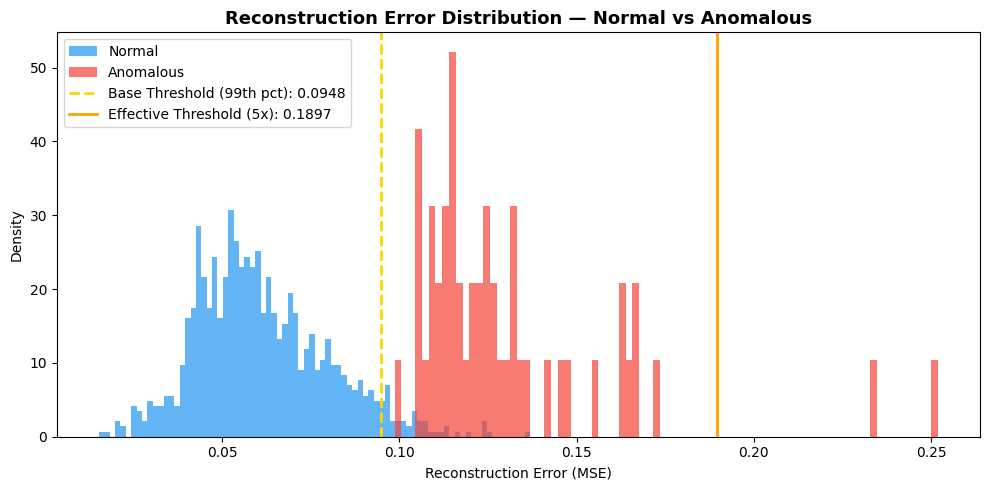

✅ Plot 1 saved


In [108]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df[~df.is_anomaly]['recon_error'],
        bins=80, alpha=0.7, color='#2196F3', label='Normal', density=True)
ax.hist(df[df.is_anomaly]['recon_error'],
        bins=80, alpha=0.7, color='#F44336', label='Anomalous', density=True)
ax.axvline(model.threshold, color='gold', linewidth=2,
           linestyle='--', label=f'Base Threshold (99th pct): {model.threshold:.4f}')
ax.axvline(effective_threshold, color='orange', linewidth=2,
           linestyle='-', label=f'Effective Threshold (5x): {effective_threshold:.4f}')

ax.set_title('Reconstruction Error Distribution — Normal vs Anomalous', fontsize=13, fontweight='bold')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('plot1_recon_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot 1 saved')

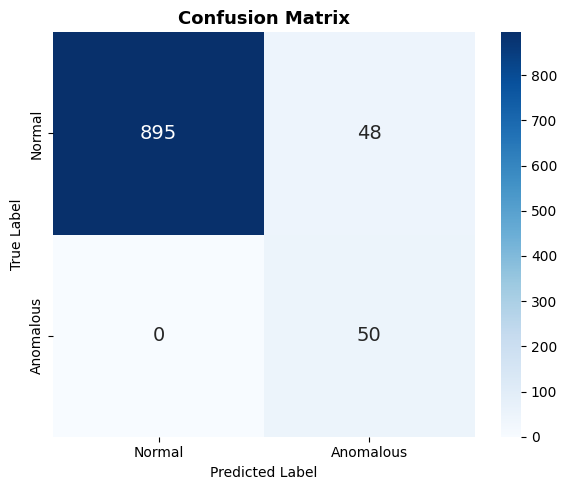

✅ Plot 2 saved


In [109]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Anomalous'],
            yticklabels=['Normal', 'Anomalous'],
            annot_kws={"size": 14})

ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('plot2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot 2 saved')

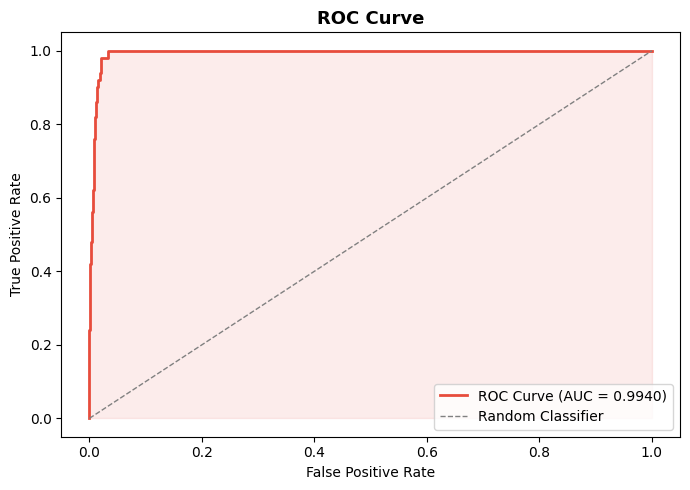

✅ Plot 3 saved


In [110]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc_val = roc_auc_score(y_true, y_score)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'ROC Curve (AUC = {auc_val:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')

ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot3_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot 3 saved')

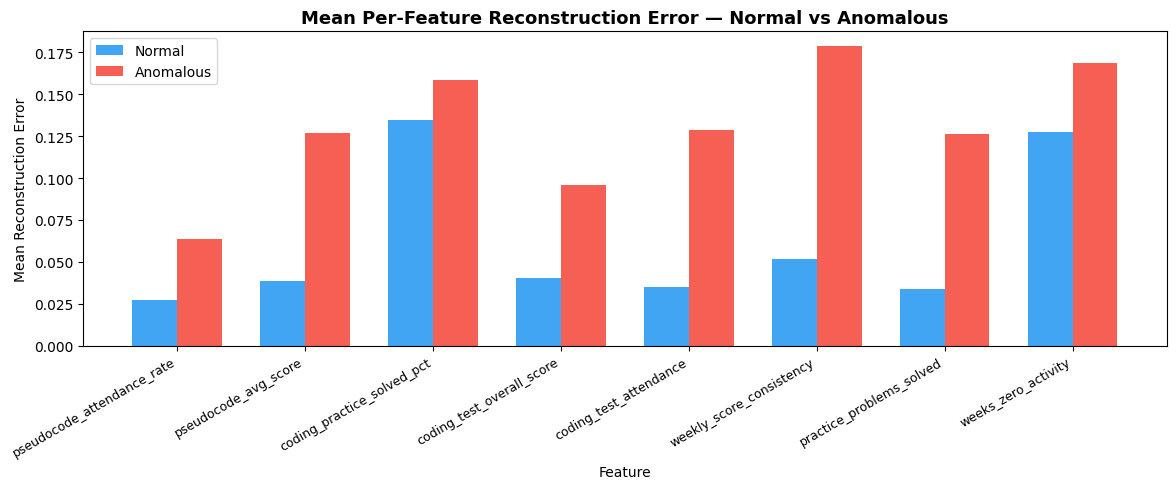

✅ Plot 4 saved


In [111]:
feature_err_cols = [f'err_{f}' for f in FEATURE_NAMES]

# Handle potential duplicate columns by selecting unique ones before calculating the mean
mean_err_normal  = df[~df.is_anomaly][feature_err_cols].iloc[:, :len(FEATURE_NAMES)].mean()
mean_err_anomaly = df[df.is_anomaly][feature_err_cols].iloc[:, :len(FEATURE_NAMES)].mean()

x     = np.arange(len(FEATURE_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - width/2, mean_err_normal.values,  width, label='Normal',    color='#2196F3', alpha=0.85)
ax.bar(x + width/2, mean_err_anomaly.values, width, label='Anomalous', color='#F44336', alpha=0.85)

ax.set_title('Mean Per-Feature Reconstruction Error — Normal vs Anomalous', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Mean Reconstruction Error')
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES, rotation=30, ha='right', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('plot4_feature_recon_error.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot 4 saved')

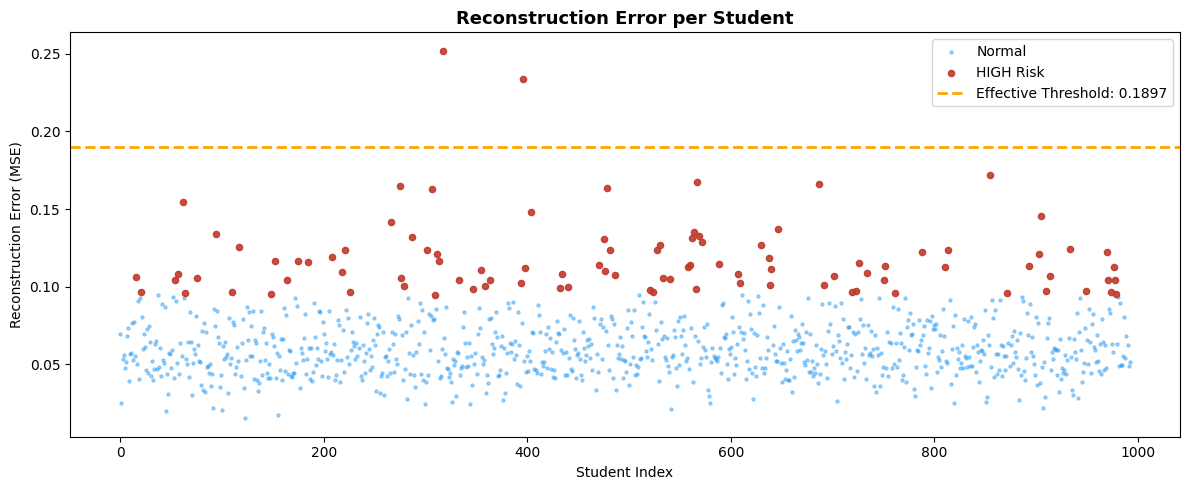

✅ Plot 5 saved


In [112]:
fig, ax = plt.subplots(figsize=(12, 5))

normal_idx  = df[~df.pred_anomaly].index
anomaly_idx = df[df.pred_anomaly].index

ax.scatter(normal_idx,  df.loc[normal_idx,  'recon_error'],
           s=5, alpha=0.4, color='#2196F3', label='Normal')
ax.scatter(anomaly_idx, df.loc[anomaly_idx, 'recon_error'],
           s=20, alpha=0.9, color='#c0392b', label='HIGH Risk', zorder=5)
ax.axhline(effective_threshold, color='orange', linewidth=2,
           linestyle='--', label=f'Effective Threshold: {effective_threshold:.4f}')

ax.set_title('Reconstruction Error per Student', fontsize=13, fontweight='bold')
ax.set_xlabel('Student Index')
ax.set_ylabel('Reconstruction Error (MSE)')
ax.legend()
plt.tight_layout()
plt.savefig('plot5_student_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot 5 saved')

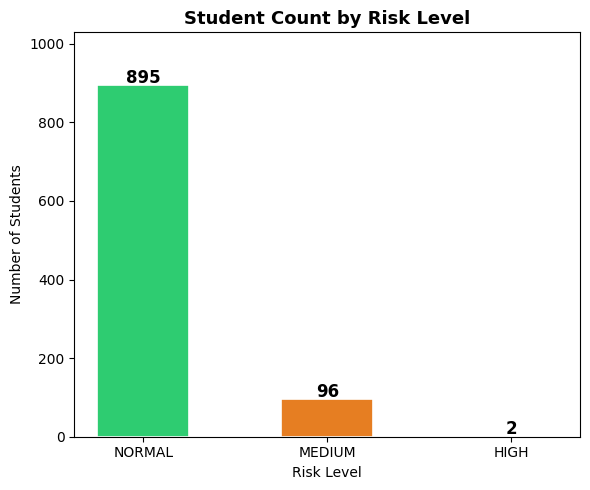

✅ Plot 6 saved


In [113]:
fig, ax = plt.subplots(figsize=(6, 5))

# Ensure order: NORMAL → MEDIUM → HIGH
order  = ['NORMAL', 'MEDIUM', 'HIGH']
colors = {'HIGH': '#c0392b', 'MEDIUM': '#e67e22', 'NORMAL': '#2ecc71'}

counts = df['pred_severity'].value_counts()
counts = counts.reindex(order, fill_value=0)  # keep fixed order

bars = ax.bar(counts.index, counts.values,
              color=[colors[s] for s in counts.index],
              edgecolor='white', linewidth=1.2, width=0.5)

for i, (k, v) in enumerate(counts.items()):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)

ax.set_title('Student Count by Risk Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Number of Students')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig('plot6_risk_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot 6 saved')

In [114]:
with open('autoencoder_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print('✅ Model saved!')
print(f'   Location  : /content/autoencoder_model.pkl')
print(f'   Threshold : {model.threshold:.6f}')

from google.colab import files
files.download('autoencoder_model.pkl')

✅ Model saved!
   Location  : /content/autoencoder_model.pkl
   Threshold : 0.094849


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>